# 0. Environment, hyperparameters and data loading

In [27]:
import optuna
import torch
from torch import nn
from torch.utils import data
import numpy as np
import pandas as pd
import pathlib
from utils.animator import Animator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'1. Using {device} device')

DATA_PATH = './kaggle/House Prices - Advanced Regression Techniques'

train_data = pd.read_csv(pathlib.Path(DATA_PATH, 'train.csv'))
test_data = pd.read_csv(pathlib.Path(DATA_PATH, 'test.csv'))

print(f"2. Successfully loaded training and testing data.\n    The shape of training data is {train_data.shape}\n    The shape of testing data is {test_data.shape}\n    The first 5 rows of training data(partial features) are:\n\n{train_data.iloc[0:5, [0,1,2,3,-3,-2,-1]]}")

batch_size = 64
K = 5
lr = 0.01
num_epochs = 2000
weight_decay = 0.001

1. Using cuda device
2. Successfully loaded training and testing data.
    The shape of training data is (1460, 81)
    The shape of testing data is (1459, 80)
    The first 5 rows of training data(partial features) are:

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000
4   5          60       RL         84.0       WD        Normal     250000


# 1. Data preprocessing

In [28]:
def preprocess(train_data, test_data):
    # Deleta the id colum
    label = 'SalePrice'    
    all_features = pd.concat((
        train_data.drop(columns=['Id', label]),
        test_data.drop(columns=['Id'])
    ))
    
    # Standardize the data
    numeric_features = all_features.select_dtypes(include=['number']).columns
    all_features[numeric_features] = all_features[numeric_features].apply(
        lambda x: (x - x.mean()) / (x.std())
    )

    # Fill the missing values with 0
    all_features[numeric_features] = all_features[numeric_features].fillna(0)
    
    # Replace the discrete values with one-hot encoding
    all_features = pd.get_dummies(all_features, dummy_na=True)
    
    Xs_train = all_features[:train_data.shape[0]]
    Xs_test = all_features[train_data.shape[0]:]
    
    # Log transform the label
    ys_train = train_data[label].apply(lambda x: np.log(x))

    return torch.from_numpy(Xs_train.values.astype(np.float32)), torch.from_numpy(ys_train.values.astype(np.float32)), torch.from_numpy(Xs_test.values.astype(np.float32))

Xs_train, ys_train, Xs_test = preprocess(train_data, test_data)

train_iter = data.DataLoader(data.TensorDataset(Xs_train, ys_train), batch_size=batch_size, shuffle=True)

print(f"Successfully preprocessed the data.\n    The shape of training data is {Xs_train.shape}\n    The shape of training labels is {ys_train.shape}\n    The shape of testing data is {Xs_test.shape}")

Successfully preprocessed the data.
    The shape of training data is torch.Size([1460, 330])
    The shape of training labels is torch.Size([1460])
    The shape of testing data is torch.Size([1459, 330])


# 2. Training

In [29]:
def train_LR(Xs, ys, num_epochs, batch_size, lr, dropouts, hidden_layers, weight_decay, device, is_display):
    if is_display:
        animator = Animator(xlabel='epoch', xlim=[1, num_epochs], legend=['train loss'])
    net = nn.Sequential(
        nn.Linear(Xs.shape[1], hidden_layers[0]),
        nn.ReLU(),
        nn.Dropout(dropouts[0]),
        )
    for i in range(1, len(hidden_layers)):
        net.append(nn.Linear(hidden_layers[i-1], hidden_layers[i]))
        net.append(nn.ReLU())
        net.append(nn.Dropout(dropouts[i]))
    net.append(nn.Linear(hidden_layers[-1], 1))
    net = net.to(device)
    loss = nn.MSELoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
    train_iter = data.DataLoader(data.TensorDataset(Xs, ys), batch_size=batch_size, shuffle=True)
    display_epoch = num_epochs // 500 if is_display else None
    if display_epoch == 0:
        display_epoch = 1
    for epoch in range(num_epochs):
        net.train()
        for X, y in train_iter:
            X, y = X.to(device), y.to(device).reshape(-1, 1)
            optimizer.zero_grad()
            l = loss(net(X.to(device)), y.to(device).reshape(-1, 1))
            l.backward()
            optimizer.step()
        net.eval()
        with torch.no_grad():
            epoch_loss = loss(
                net(Xs.to(device)), ys.to(device).reshape(-1, 1)).item()
        if is_display and epoch % display_epoch == 0:
            animator.add(epoch + 1, (epoch_loss,))
    if is_display:
        animator.close()
    return net, epoch_loss
        
def f_fold_data(k, Xs: torch.Tensor, ys: torch.Tensor):
    folds = []
    fold_size = Xs.shape[0] // k
    for i in range(k):
        parts_X, parts_y = [], []
        for j in range(k):
            if j == i:
                continue
            idx = slice(j * fold_size, (j + 1) * fold_size)
            parts_X.append(Xs[idx])
            parts_y.append(ys[idx])
        folds.append((torch.cat(parts_X), torch.cat(parts_y)))
    return folds
        
def k_fold(trainer, Xs, ys, num_epochs, batch_size, K, lr, dropouts, hidden_layers, weight_decay, device, is_display=False):
    val_loss, models = [], []
    for i, (Xs_fold, ys_fold) in enumerate(f_fold_data(K, Xs, ys)):
        if is_display:
            print(f'Fold {i+1} starts')
        if i == 0 and is_display:
            is_display = True
        else:
            is_display = False
        model, loss = trainer(Xs_fold, ys_fold, num_epochs, batch_size, lr, dropouts, hidden_layers, weight_decay, device, is_display)
        models.append(model)
        val_loss.append(loss)
    avg_loss = sum(val_loss) / len(val_loss)
    if is_display:
        print(f'{K}-fold validation: avg loss {avg_loss:.6f}')
    return models, avg_loss

In [30]:
#models = k_fold(train_LR, Xs_train, ys_train, num_epochs, batch_size, K, lr, weight_decay, device)

# 3. Optimize the hyperparameters

In [31]:
def objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128, 256])
    n_layers = trial.suggest_int('n_layers', 1, 5)
    hidden_layers = []
    dropouts = []
    for i in range(n_layers):
        hidden_layers.append(trial.suggest_int(f'hidden_layer_{i}', 128, 512, step=64))
        dropouts.append(trial.suggest_float(f'dropout_{i}', 0.1, 0.5, step=0.1))
    K = trial.suggest_int('K', 3, 10)
    tune_epochs = 300
    _, avg_loss = k_fold(
        train_LR, Xs_train, ys_train, tune_epochs, batch_size, K, lr, dropouts, hidden_layers, weight_decay, device, False)
    return avg_loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print(f"Best trial: {study.best_trial.params}")
print(f"Best value: {study.best_trial.value:.6f}")
print('-' * 20)
print(study.trials_dataframe())

[I 2026-06-11 13:49:10,285] A new study created in memory with name: no-name-5b1b5aab-53be-4f73-add0-74e6876b703e
[I 2026-06-11 13:50:11,520] Trial 0 finished with value: 0.048191832999388375 and parameters: {'lr': 0.002815498646540434, 'weight_decay': 5.737978471577985e-05, 'batch_size': 16, 'n_layers': 5, 'hidden_layer_0': 320, 'dropout_0': 0.5, 'hidden_layer_1': 128, 'dropout_1': 0.30000000000000004, 'hidden_layer_2': 320, 'dropout_2': 0.1, 'hidden_layer_3': 192, 'dropout_3': 0.2, 'hidden_layer_4': 448, 'dropout_4': 0.4, 'K': 3}. Best is trial 0 with value: 0.048191832999388375.
[I 2026-06-11 13:50:21,239] Trial 1 finished with value: 0.053673996279637017 and parameters: {'lr': 0.0073380407622753545, 'weight_decay': 0.00012291346241620352, 'batch_size': 128, 'n_layers': 4, 'hidden_layer_0': 192, 'dropout_0': 0.5, 'hidden_layer_1': 256, 'dropout_1': 0.1, 'hidden_layer_2': 448, 'dropout_2': 0.1, 'hidden_layer_3': 320, 'dropout_3': 0.4, 'K': 3}. Best is trial 0 with value: 0.0481918329

Best trial: {'lr': 0.0005845480347133517, 'weight_decay': 2.5987545425438604e-06, 'batch_size': 16, 'n_layers': 4, 'hidden_layer_0': 320, 'dropout_0': 0.2, 'hidden_layer_1': 384, 'dropout_1': 0.2, 'hidden_layer_2': 448, 'dropout_2': 0.5, 'hidden_layer_3': 448, 'dropout_3': 0.4, 'K': 4}
Best value: 0.012235
--------------------
    number      value             datetime_start          datetime_complete  \
0        0   0.048192 2026-06-11 13:49:10.286026 2026-06-11 13:50:11.520664   
1        1   0.053674 2026-06-11 13:50:11.521383 2026-06-11 13:50:21.239179   
2        2   0.039222 2026-06-11 13:50:21.239844 2026-06-11 13:50:28.879067   
3        3   0.018261 2026-06-11 13:50:28.879758 2026-06-11 13:51:07.994993   
4        4   0.030610 2026-06-11 13:51:07.995742 2026-06-11 13:51:39.364468   
5        5   0.055296 2026-06-11 13:51:39.365424 2026-06-11 13:52:29.635913   
6        6   0.047405 2026-06-11 13:52:29.636615 2026-06-11 13:52:46.056851   
7        7   0.203166 2026-06-11 13:52:

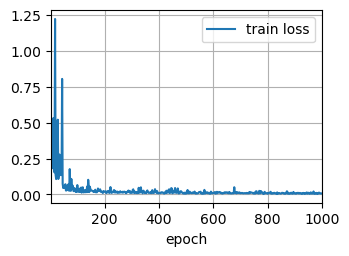

Fold 2 starts
The average loss of the 5-fold cross validation is 0.007404


In [34]:
best_lr = study.best_trial.params['lr']
best_weight_decay = study.best_trial.params['weight_decay']
best_batch_size = study.best_trial.params['batch_size']
best_K = study.best_trial.params['K']
best_epochs = 1000
best_n_layers = study.best_trial.params['n_layers']
best_hidden_layers = []
best_dropouts = []  
for i in range(best_n_layers):
    best_hidden_layers.append(study.best_trial.params[f'hidden_layer_{i}'])
    best_dropouts.append(study.best_trial.params[f'dropout_{i}'])

models, avg_loss = k_fold(train_LR, Xs_train, ys_train, best_epochs, best_batch_size, best_K, best_lr, best_dropouts, best_hidden_layers, best_weight_decay, device, True)
print(f"The average loss of the {K}-fold cross validation is {avg_loss:.6f}")

In [35]:
predictions = []
for model in models:
    model.eval()
    with torch.no_grad():
        y_pred = model(Xs_test.to(device))
        y_pred = torch.exp(y_pred)
        y_pred = y_pred.cpu().numpy()
        y_pred = y_pred.reshape(-1)
        predictions.append(y_pred)
prediction = np.mean(predictions, axis=0)
pd.DataFrame({'Id': test_data['Id'], 'SalePrice': prediction}).to_csv('./submission.csv', index=False)